In [2]:
import numpy as np
import pandas as pd

X = np.array([
    [1.0, 2],
    [1.2, 2],
    [1.4, 3],
    [1.5, 3],
    [1.7, 3],
    [1.8, 4],
    [2.0, 4],
    [2.1, 4],
    [2.3, 4],
    [2.4, 5],
    [2.6, 5],
    [2.8, 5],
    [3.0, 5],
    [3.2, 6],
    [3.5, 6]
])

X = np.c_[np.ones(X.shape[0]), X]

y = np.array([
    32, 36, 43, 46, 50,
    55, 59, 62, 66, 72,
    76, 81, 85, 91, 98
])

X_train = X[:11]
y_train = y[:11]

X_test = X[11:]
y_test = y[11:]


theta = np.array([0.0, 0.0, 0.0])

learning_rate = 0.01
iterations = 10000;
m = len(X_train)

In [3]:
for i in range(iterations):
    gradient = np.array([0.0, 0.0, 0.0])
    for j in range(m):
        x1 = X_train[j][1]
        x2 = X_train[j][2]

        hx = theta[0] + theta[1]*x1 + theta[2]*x2

        error = hx - y_train[j]

        gradient[0] += error * 1
        gradient[1] += error * x1
        gradient[2] += error * x2
    gradient[0] /= m
    gradient[1] /= m
    gradient[2] /= m
    theta[0] -= learning_rate * gradient[0]
    theta[1] -= learning_rate * gradient[1]
    theta[2] -= learning_rate * gradient[2]

print(theta)

[ 4.02726818 18.72745421  4.56993583]


In [4]:
myx1 = 3.5
myx2 = 6
print(theta[0] + theta[1]*myx1 + theta[2]*myx2)

96.99297290524503


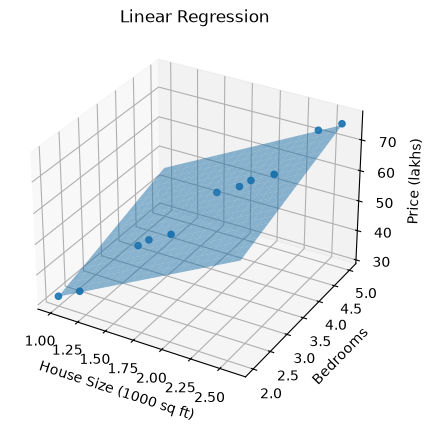

In [5]:
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure()

# Create 3D axes
ax = fig.add_subplot(111, projection='3d')

# Plot actual training data
ax.scatter(
    X_train[:, 1],
    X_train[:, 2],
    y_train,
    label="Training Data"
)

# Create values for the plane
x1_values = np.linspace(
    X_train[:, 1].min(),
    X_train[:, 1].max(),
    20
)

x2_values = np.linspace(
    X_train[:, 2].min(),
    X_train[:, 2].max(),
    20
)

x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)

# Calculate predictions for every point on the plane
y_grid = (
    theta[0]
    + theta[1] * x1_grid
    + theta[2] * x2_grid
)

# Plot regression plane
ax.plot_surface(
    x1_grid,
    x2_grid,
    y_grid,
    alpha=0.5
)

ax.set_xlabel("House Size (1000 sq ft)")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price (lakhs)")

ax.set_title("Linear Regression")

plt.show()